# 1. ECG Signal Characteristics and Components

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from _nb_helper import save_plot, setup_notebook

from ecg_waveform.config import load_yaml
from ecg_waveform.core import Fiducials
from ecg_waveform.signal.quality import SignalQualityAssessor
from ecg_waveform.signal.simulation import NoiseComponent, NoiseConfig, simulate_ecg
from ecg_waveform.utils import compute_rr_intervals, compute_snr
from ecg_waveform.visualization import (
    plot_average_beat,
    plot_signal,
    plot_psd,
    plot_fft,
    plot_poincare,
    plot_rr_distribution,
    plot_rr_tachogram,
)

setup_notebook()

In [2]:
DURATION_SEC: float = 300.0
SAMPLE_RATE: int = 500
HEART_RATE_BPM: float = 60.0
HRV_STD_SEC: float = 0.03
RANDOM_SEED: int = 42

In [3]:
assessor_config = load_yaml("quality/quality_assessment_config.yaml")
assessor = SignalQualityAssessor.from_config(assessor_config)

---

In [4]:
reference_signal = simulate_ecg(
    duration_sec=DURATION_SEC,
    sample_rate=SAMPLE_RATE,
    heart_rate_bpm=HEART_RATE_BPM,
    hrv_std_sec=HRV_STD_SEC,
    noise=None,
    seed=RANDOM_SEED,
)

reference_r_peaks = reference_signal.annotation.filter(Fiducials.R_PEAK.value)

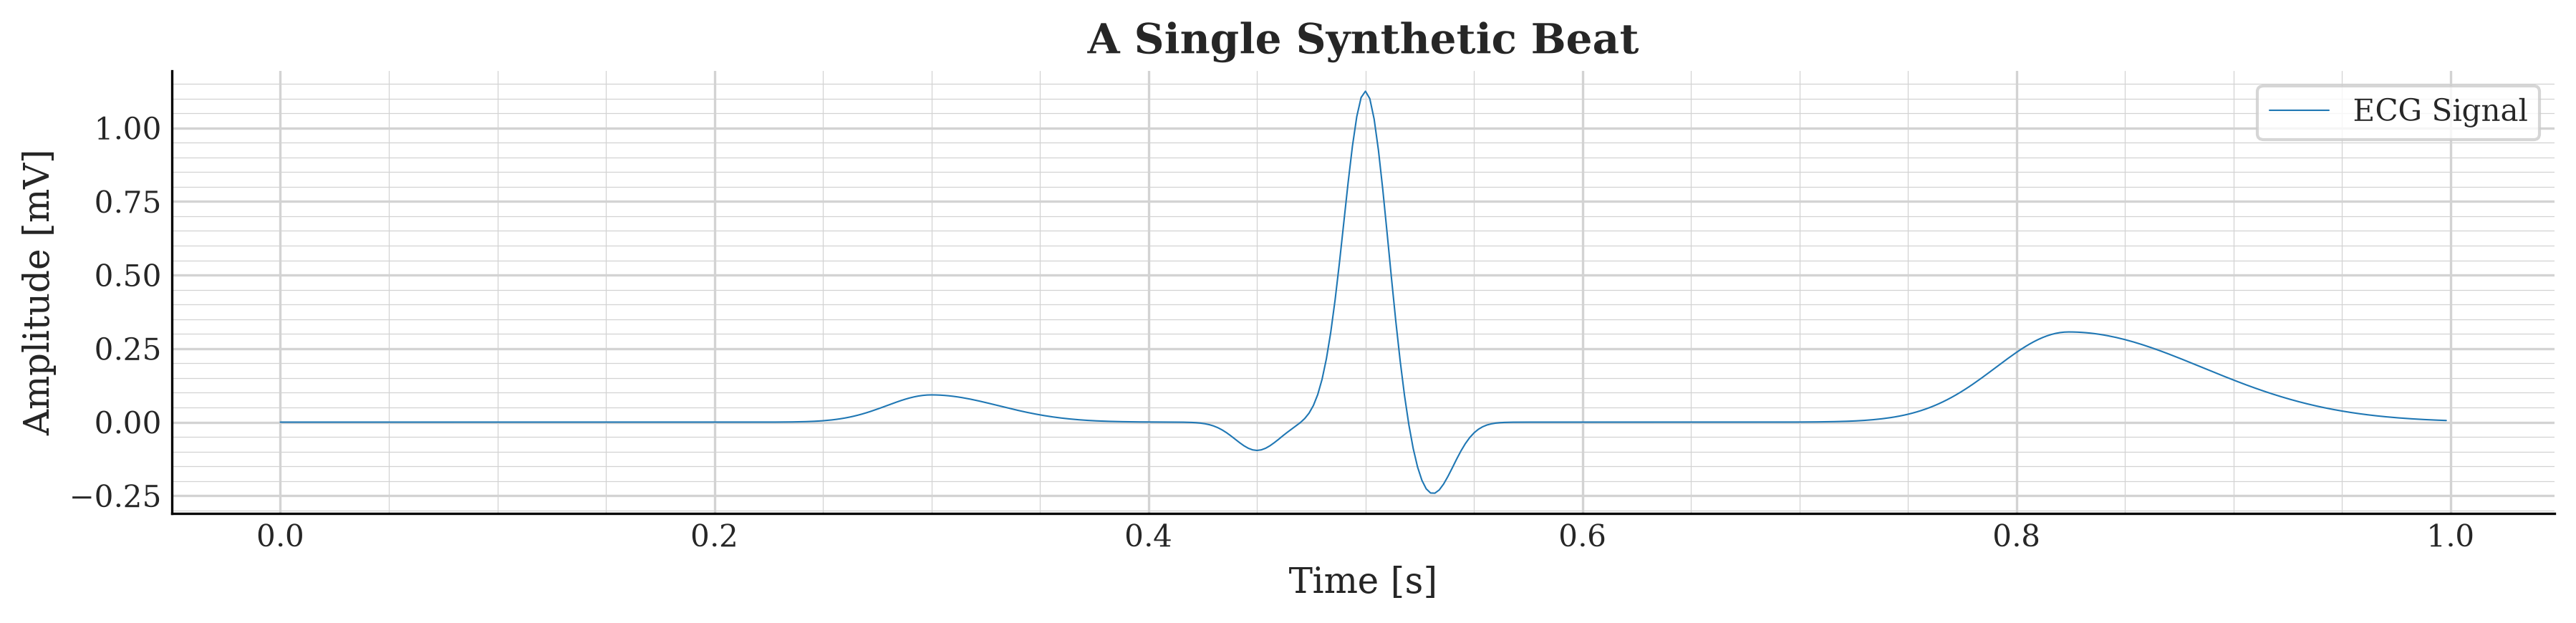

In [5]:
fig, ax = plot_signal(
    reference_signal,
    start_sec=0,
    interval_sec=1.0,
    show_annotation=False,
    title="A Single Synthetic Beat",
)

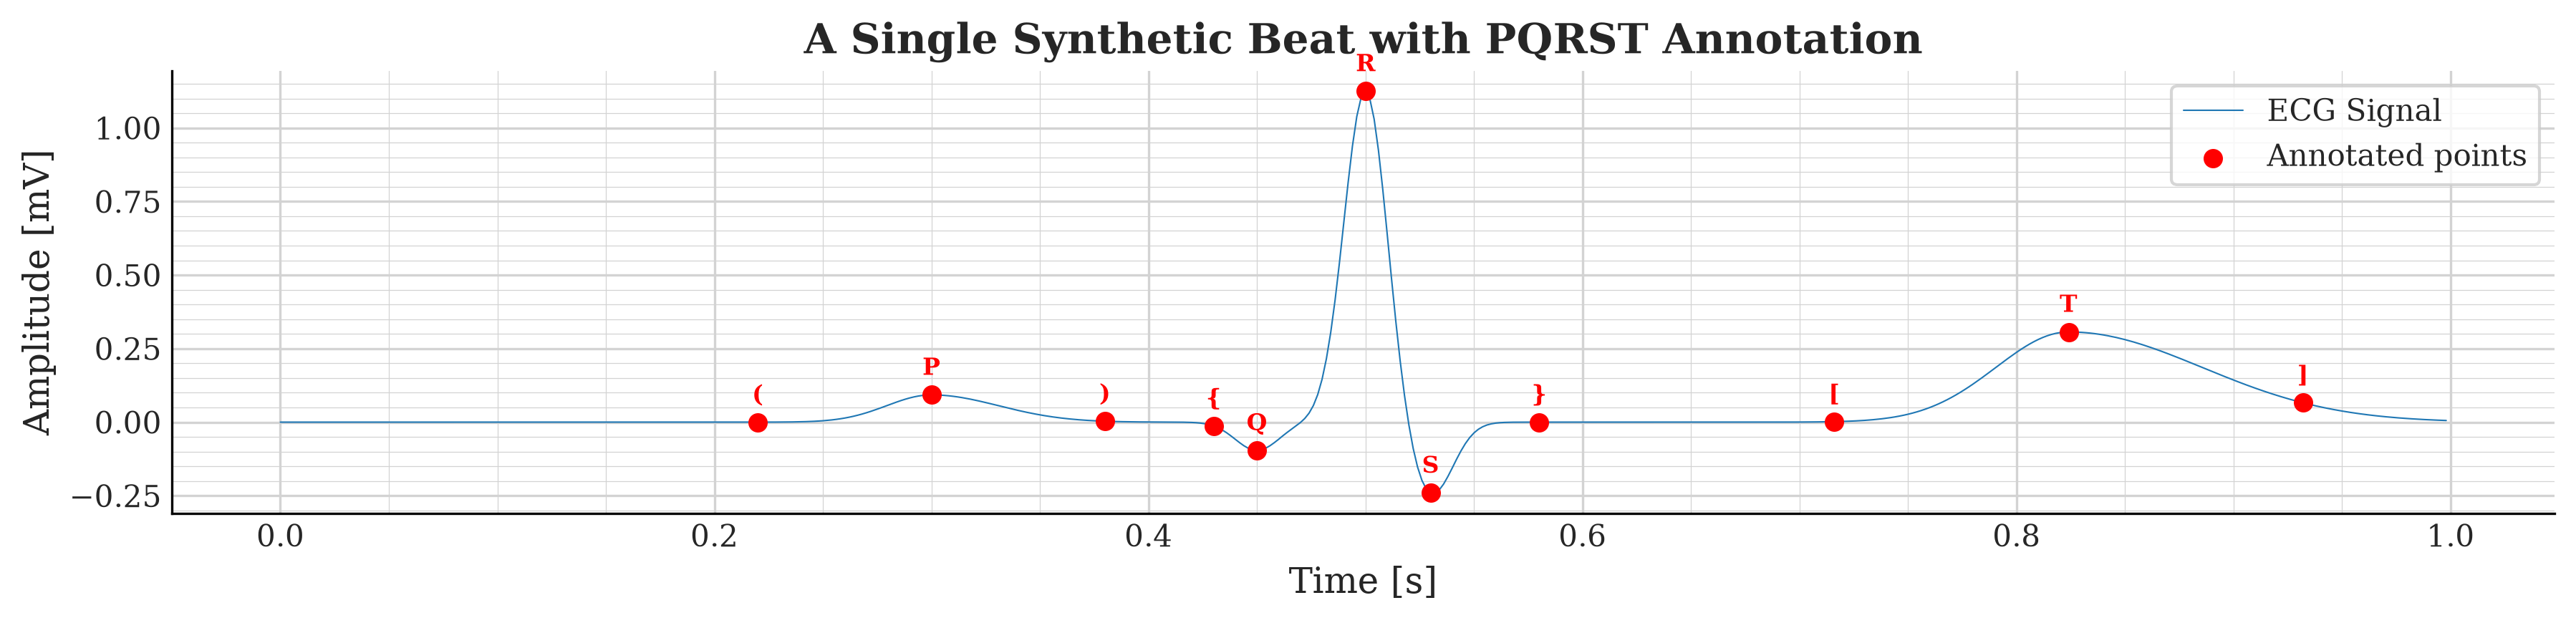

In [6]:
fig, ax = plot_signal(
    reference_signal,
    start_sec=0,
    interval_sec=1.0,
    show_annotation=True,
    title="A Single Synthetic Beat with PQRST Annotation",
)

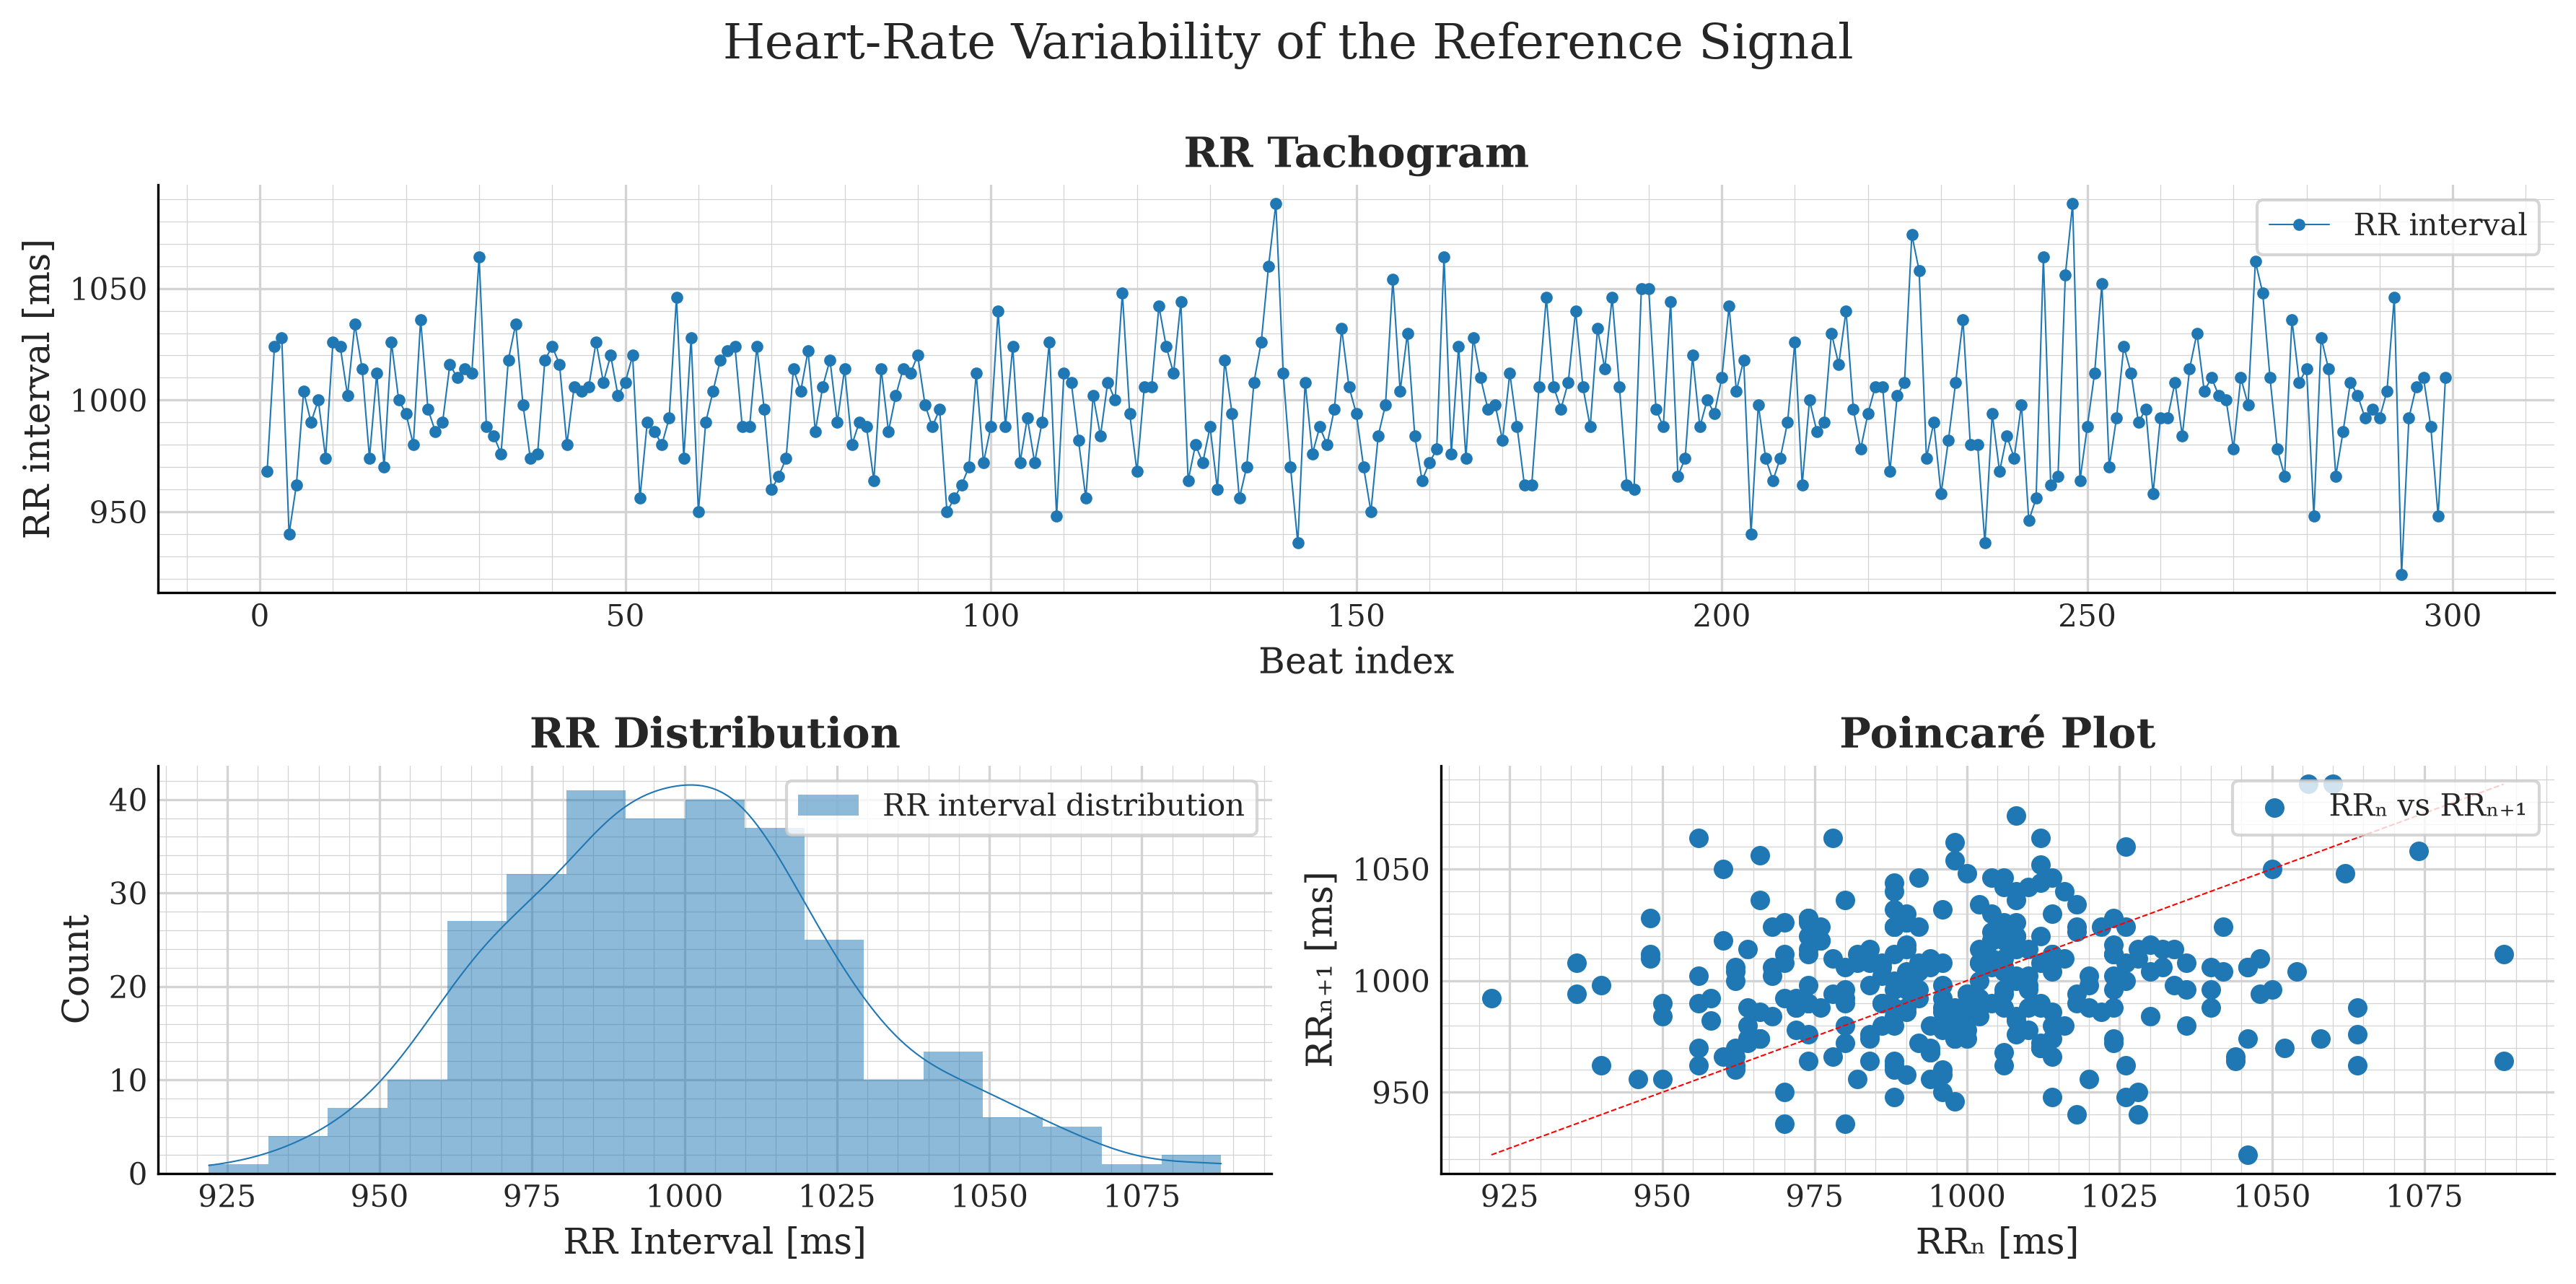

In [7]:
fig = plt.figure(figsize=(12, 6))

gs = fig.add_gridspec(nrows=2, ncols=2)

ax_top = fig.add_subplot(gs[0, :])
ax_left = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])

plot_rr_tachogram(reference_signal, reference_r_peaks, ax=ax_top)
plot_rr_distribution(reference_signal, reference_r_peaks, ax=ax_left)
plot_poincare(reference_signal, reference_r_peaks, ax=ax_right)

fig.suptitle("Heart-Rate Variability of the Reference Signal", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))

In [8]:
rr_intervals_ms = compute_rr_intervals(reference_signal, reference_r_peaks)

print(
    f"Nominal mean RR intervals: {60000 / HEART_RATE_BPM} ms, "
    f"std: {HRV_STD_SEC * 1000} ms "
    f"({HEART_RATE_BPM} bpm)"
)
print(
    f"Observed mean RR intervals: {np.mean(rr_intervals_ms):.1f} ms, "
    f"std: {np.std(rr_intervals_ms):.1f} ms "
    f"({60000 / np.mean(rr_intervals_ms):.1f} bpm)"
)

Nominal mean RR intervals: 1000.0 ms, std: 30.0 ms (60.0 bpm)
Observed mean RR intervals: 998.7 ms, std: 27.9 ms (60.1 bpm)


In [9]:
NOISE_CONFIGS = {
    "Baseline wander": NoiseConfig(NoiseComponent.BASELINE_WANDER),
    "Powerline interference": NoiseConfig(NoiseComponent.POWERLINE_INTERFERENCE),
    "EMG/ muscle noise": NoiseConfig(NoiseComponent.MUSCLE_NOISE),
    "White noise": NoiseConfig(NoiseComponent.WHITE_NOISE),
    "Combined noise": NoiseConfig(NoiseComponent.ALL),
}

SIGNALS = {
    name: simulate_ecg(
        duration_sec=DURATION_SEC,
        sample_rate=SAMPLE_RATE,
        heart_rate_bpm=HEART_RATE_BPM,
        hrv_std_sec=HRV_STD_SEC,
        noise=config,
        seed=RANDOM_SEED,
    )
    for name, config in NOISE_CONFIGS.items()
}

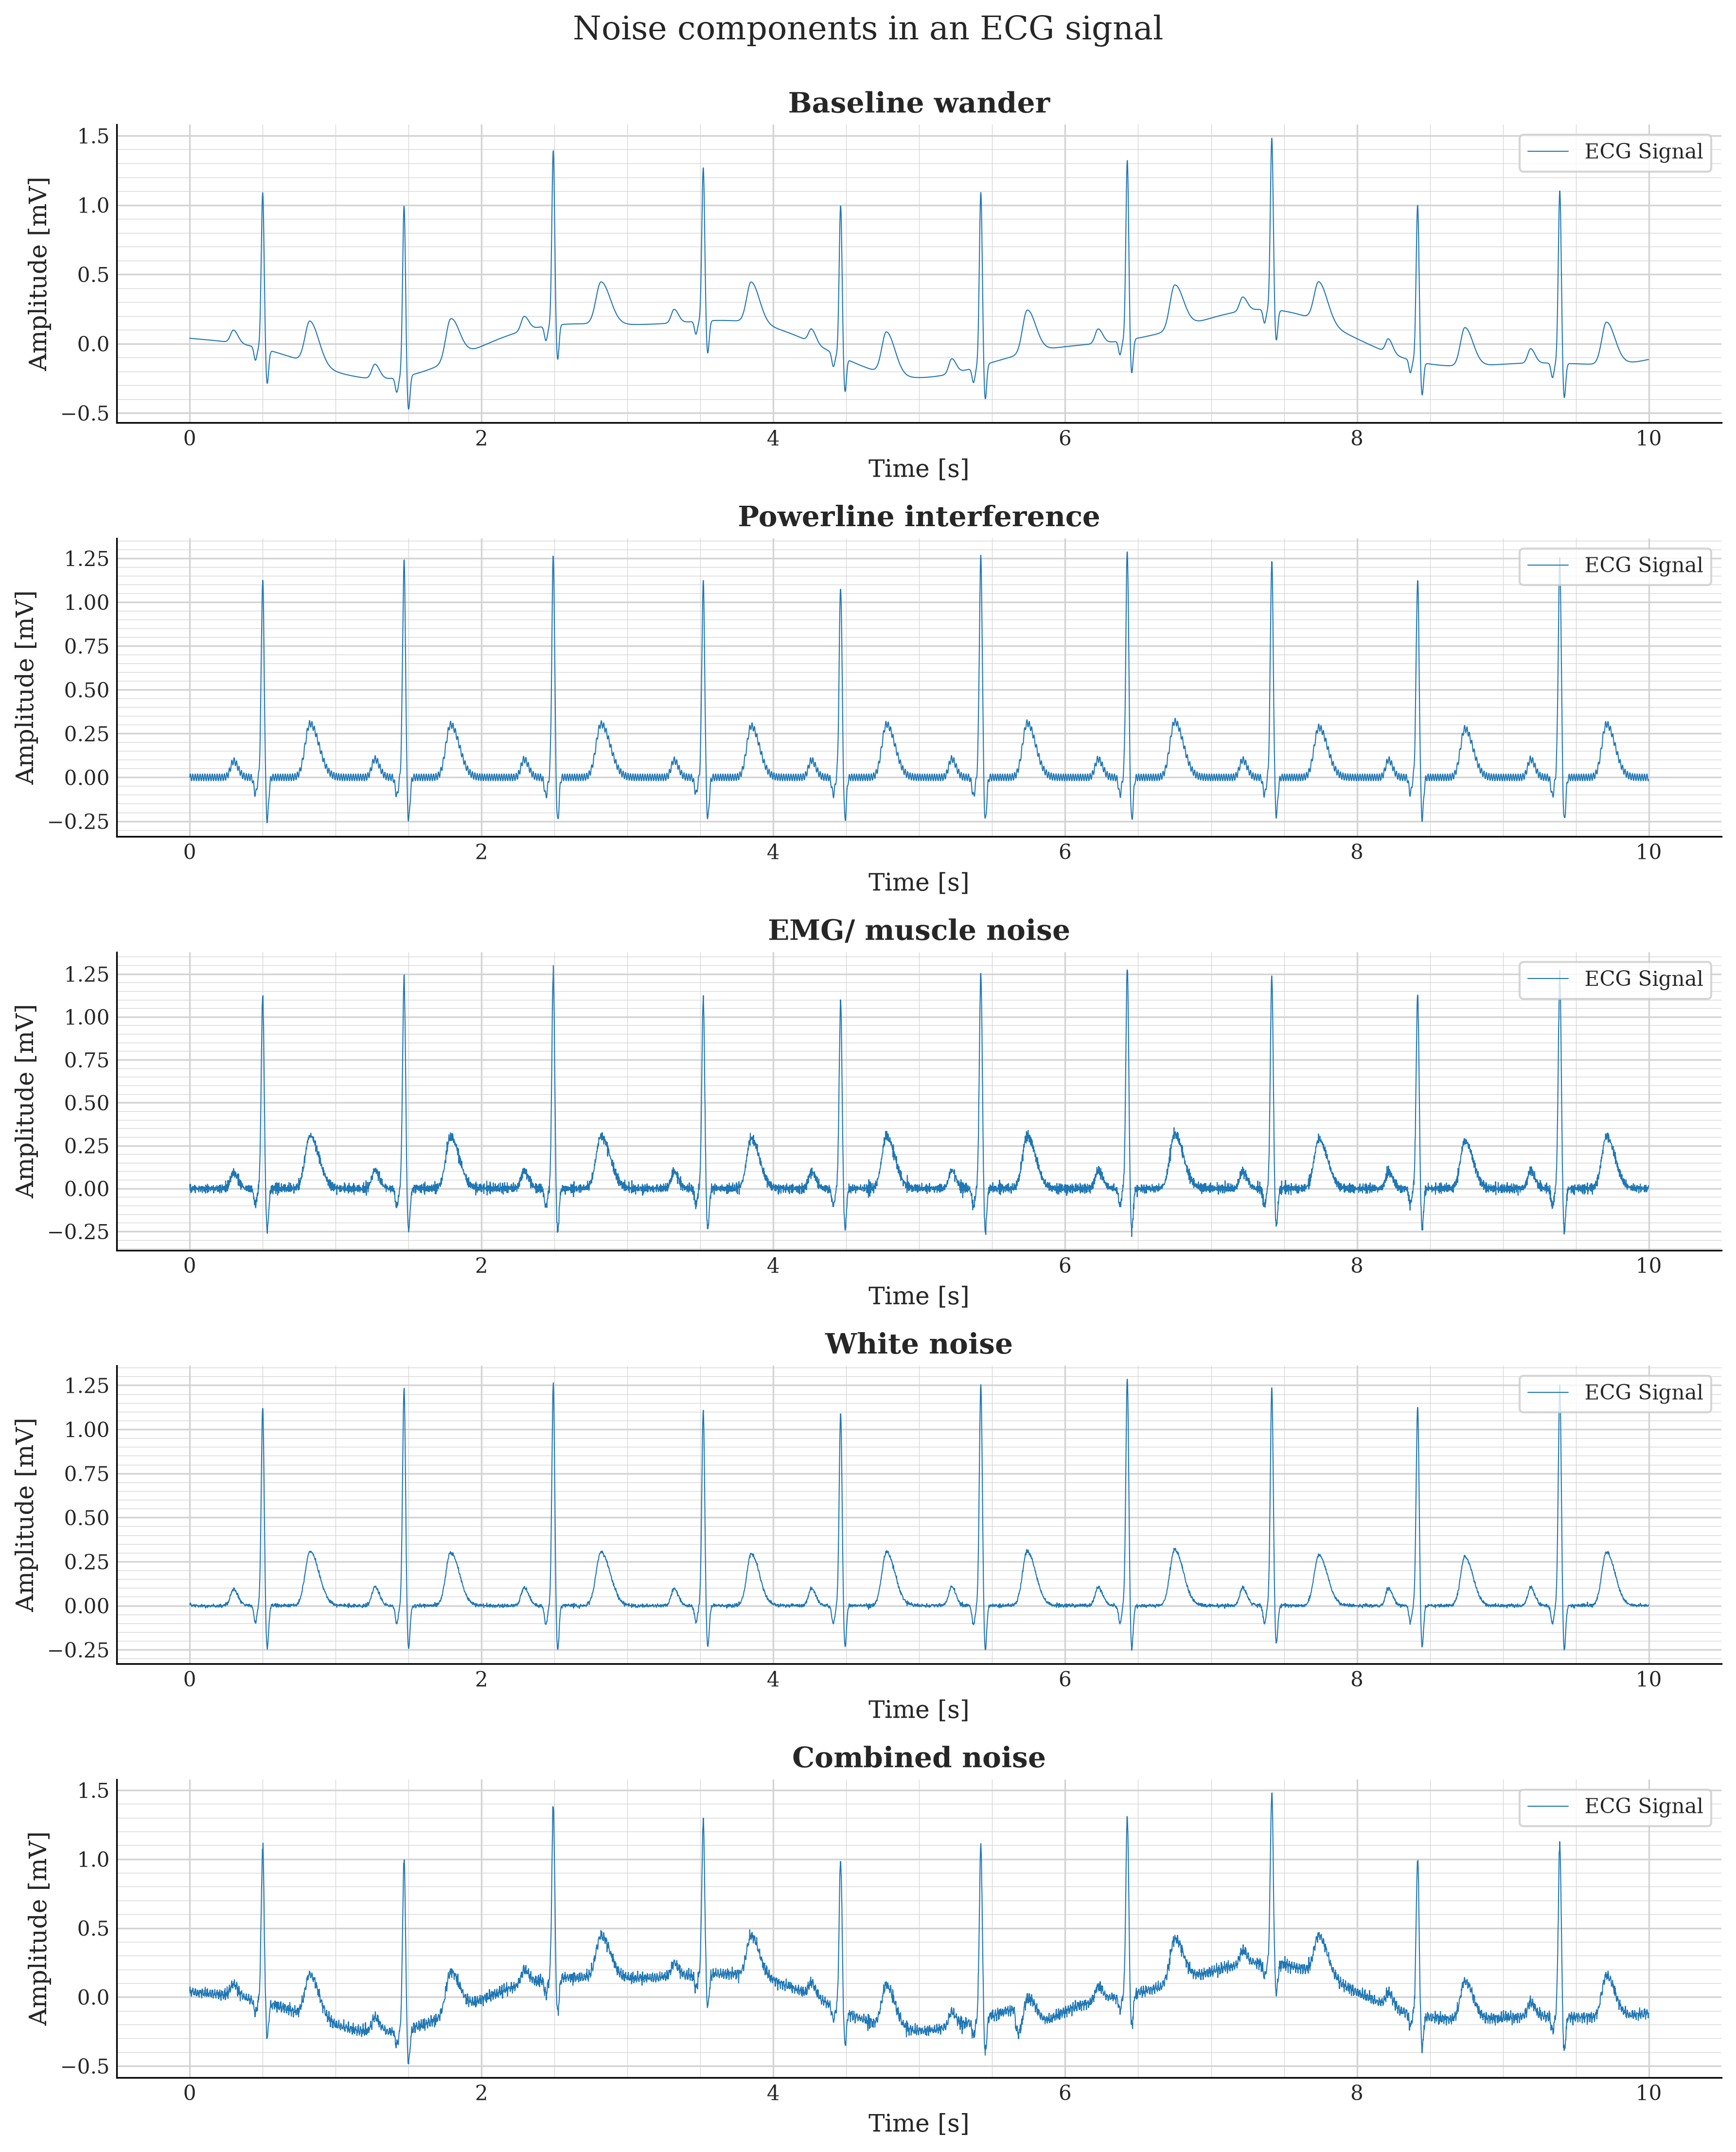

In [10]:
fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(12, 3 * len(SIGNALS)))

axes = np.atleast_1d(axes).ravel()

for ax, (name, signal) in zip(axes, SIGNALS.items()):
    plot_signal(
        signal,
        title=name,
        show_annotation=False,
        interval_sec=10,
        ax=ax,
    )

fig.suptitle("Noise components in an ECG signal", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))

save_plot(fig, "Signal noise components")

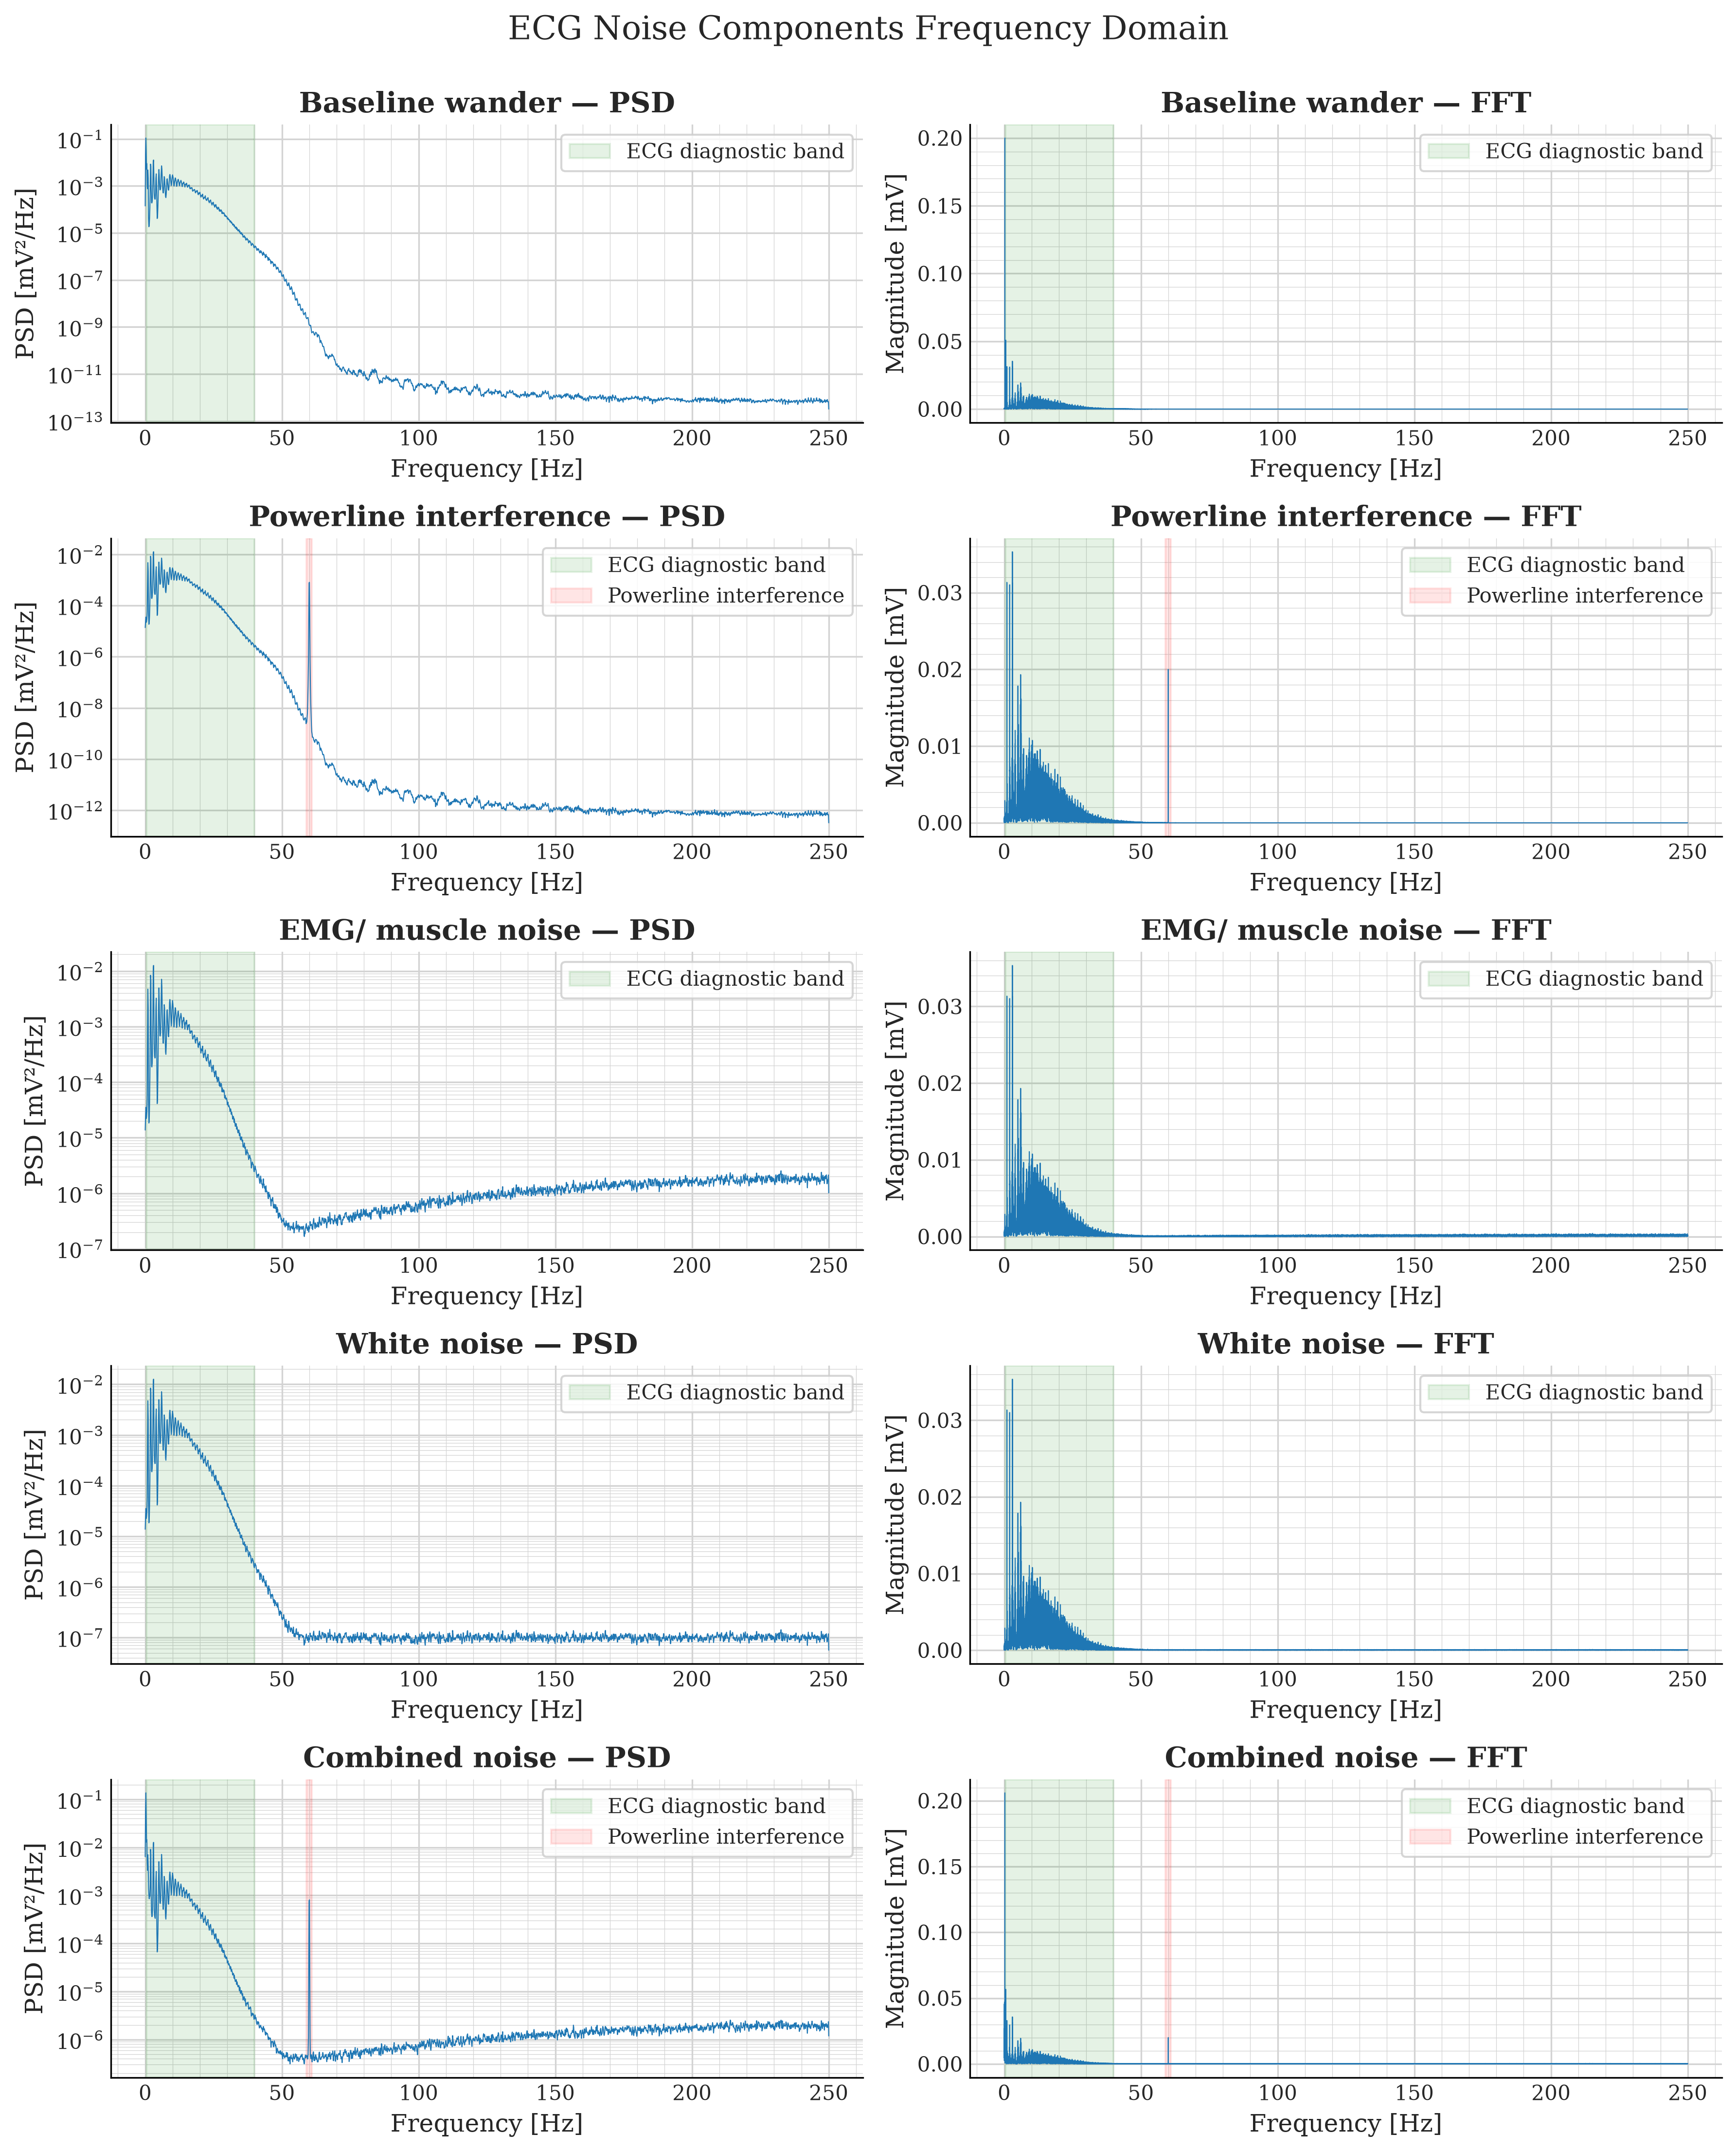

In [11]:
fig, axes = plt.subplots(len(SIGNALS), 2, figsize=(12, 3 * len(SIGNALS)))

axes = np.atleast_2d(axes)

for row, (name, signal) in enumerate(SIGNALS.items()):
    config = NOISE_CONFIGS[name]

    plot_psd(signal, title=f"{name} — PSD", ax=axes[row, 0])
    plot_fft(signal, title=f"{name} — FFT", ax=axes[row, 1])

    for ax in axes[row]:
        ax.axvspan(0.5, 40, color="green", alpha=0.1, label="ECG diagnostic band")

        if config.has(NoiseComponent.POWERLINE_INTERFERENCE):
            ax.axvspan(59, 61, color="red", alpha=0.1, label="Powerline interference")

        ax.legend()

fig.suptitle("ECG Noise Components Frequency Domain", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))

save_plot(fig, "ECG noise components frequency domains")

In [12]:
raw_signal = simulate_ecg(
    duration_sec=DURATION_SEC,
    sample_rate=SAMPLE_RATE,
    heart_rate_bpm=HEART_RATE_BPM,
    hrv_std_sec=HRV_STD_SEC,
    seed=RANDOM_SEED,
)

In [13]:
snr = compute_snr(reference_signal, raw_signal)

print(f"SNR = {snr:.2f} dB")

result = assessor.assess(raw_signal)

print(result)

SNR = -0.79 dB
QualityReport[BAD, score=0.80]
  kurtosis_sqi           =   4.4548  [ACCEPTABLE]
  qrs_power_sqi          =   0.4775  [GOOD]
  powerline_50hz         =   0.0000  [GOOD]
  powerline_60hz         =   0.0031  [GOOD]
  baseline_wander_ratio  =   0.4983  [BAD]
  flatline_ratio         =   0.0000  [GOOD]


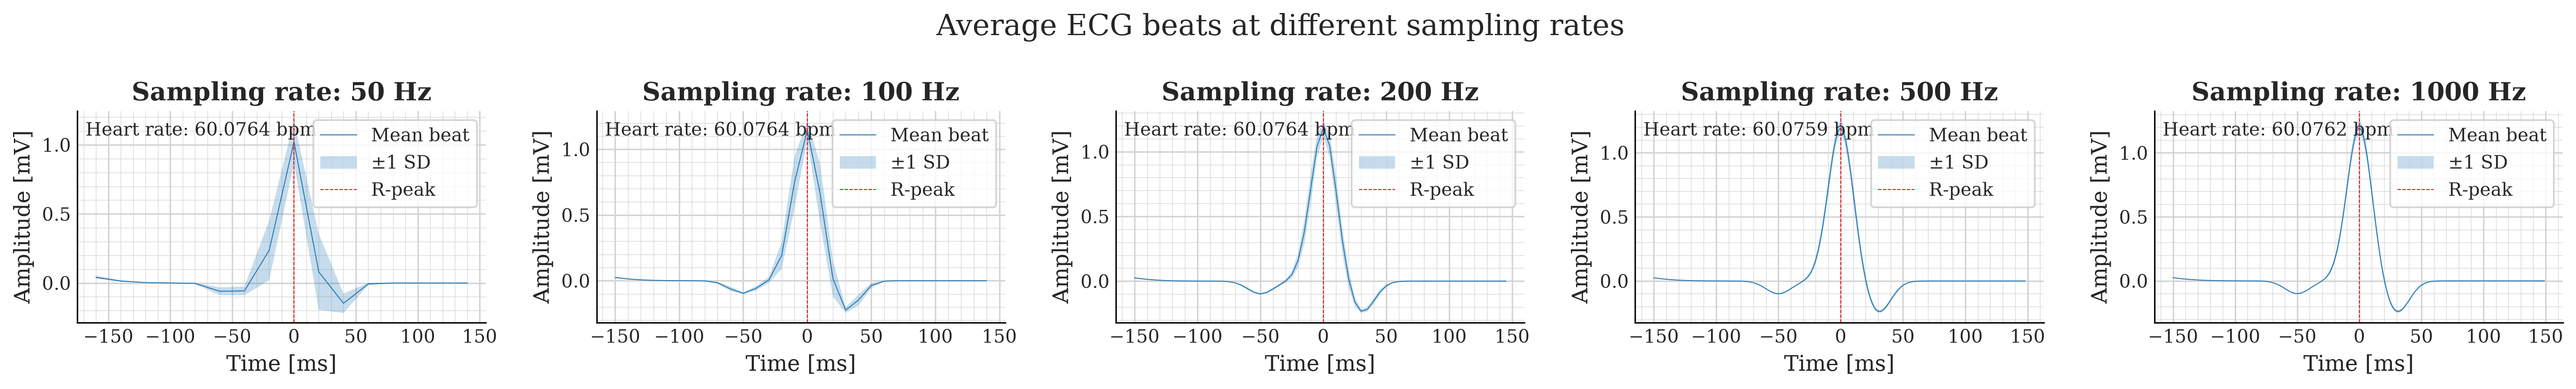

In [15]:
SAMPLING_RATES = (50, 100, 200, 500, 1000)

fig, axes = plt.subplots(1, len(SAMPLING_RATES), figsize=(4 * len(SAMPLING_RATES), 3))

axes = np.atleast_1d(axes).ravel()

for ax, sample_rate in zip(axes, SAMPLING_RATES):
    signal = simulate_ecg(
        duration_sec=DURATION_SEC,
        sample_rate=sample_rate,
        heart_rate_bpm=HEART_RATE_BPM,
        hrv_std_sec=HRV_STD_SEC,
        noise=None,
        seed=RANDOM_SEED,
    )

    r_peaks = signal.annotation.filter(Fiducials.R_PEAK.value)

    plot_average_beat(
        signal,
        r_peaks,
        window_ms=(150, 150),
        title=f"Sampling rate: {sample_rate} Hz",
        ax=ax,
    )

    rr_intervals_ms = compute_rr_intervals(signal, r_peaks)
    heart_rate = 60000 / np.mean(rr_intervals_ms)

    ax.text(
        0.02,
        0.95,
        f"Heart rate: {heart_rate:.4f} bpm",
        transform=ax.transAxes,
        va="top",
    )

fig.suptitle("Average ECG beats at different sampling rates", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))

save_plot(fig, "Average beats by sampling rate")

---